# ch04/gradient_1d.py

In [ ]:
import numpy as np
import matplotlib.pylab as plt


def numerical_diff(f, x):
    h = 1e-4 # 0.0001
    return (f(x+h) - f(x-h)) / (2*h)


def function_1(x):
    #return 0.01*x**2 + 0.1*x 
    return x**2

def tangent_line(f, x):
    # 1. 求 f 在 x 处的导数（切线斜率）
    d = numerical_diff(f, x)
    
    # 2. 打印斜率，方便看结果
    print(d)
    
    # 3. 计算切线方程 y = kx + b 里的截距 b
    b = f(x) - d*x
    
    # 4. 返回切线方程：输入 t，返回切线上的函数值
    return lambda t: d*t + b

     
x = np.arange(0.0, 20.0, 0.1)
y = function_1(x)
plt.xlabel("x")
plt.ylabel("f(x)")

tf = tangent_line(function_1, 7)
y2 = tf(x)

plt.plot(x, y)
plt.plot(x, y2)
plt.show()


# ch04/gradient_2d.py

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ---------------------- 数值梯度不变 ----------------------
def _numerical_gradient_no_batch(f, x):
    h = 1e-4
    grad = np.zeros_like(x)
    for idx in range(x.size):
        tmp_val = x[idx]
        x[idx] = float(tmp_val) + h
        fxh1 = f(x)
        x[idx] = tmp_val - h
        fxh2 = f(x)
        grad[idx] = (fxh1 - fxh2) / (2*h)
        x[idx] = tmp_val
    return grad

def numerical_gradient(f, X):
    if X.ndim == 1:
        return _numerical_gradient_no_batch(f, X)
    else:
        grad = np.zeros_like(X)
        for idx, x in enumerate(X):
            grad[idx] = _numerical_gradient_no_batch(f, x)
        return grad

# ---------------------- 在这里切换函数 ----------------------
def func(x):
    x0, x1 = x[0], x[1]

    # 【基础函数】
    # 1. 碗型二次函数
    # return x0**2 + x1**2

    # 2. 正弦波浪
    return np.sin(x0) + np.sin(x1)

    # 3. 余弦波浪
    # return np.cos(x0) + np.cos(x1)

    # 4. 交叉正弦
    # return np.sin(x0 * x1)

    # 5. 高斯钟形山丘
    # return -np.exp(-(x0**2 + x1**2))

    # 6. 指数函数
    # return np.exp(x0) + np.exp(x1)

    # 7. 马鞍面鞍点
    # return x0**2 - x1**2

    # 【神经网络激活函数】
    # 8. Sigmoid
    # return 1/(1+np.exp(-x0)) + 1/(1+np.exp(-x1))

    # 9. Tanh 双曲正切
    # return np.tanh(x0) + np.tanh(x1)

    # 10. ReLU 激活函数
    # return np.maximum(0, x0) + np.maximum(0, x1)

# ---------------------- 画图：3D曲面 + 2D梯度箭头 ----------------------
if __name__ == '__main__':
    # 生成网格点
    x0 = np.arange(-2, 2.5, 0.25)
    x1 = np.arange(-2, 2.5, 0.25)
    X, Y = np.meshgrid(x0, x1)
    row, col = X.shape

    # 计算每个点的函数值 Z
    Z = np.zeros_like(X)
    for i in range(row):
        for j in range(col):
            Z[i,j] = func(np.array([X[i,j], Y[i,j]]))

    # 计算梯度（用于画平面箭头）
    X_flat = X.flatten()
    Y_flat = Y.flatten()
    grad = numerical_gradient(func, np.array([X_flat, Y_flat]).T).T

    # 创建画布
    fig = plt.figure(figsize=(12,5))

    # 左图：3D 曲面
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
    ax1.set_xlabel('x0')
    ax1.set_ylabel('x1')
    ax1.set_zlabel('f(x0,x1)')
    # ax1.set_title('3D 函数曲面')

    # 右图：2D 负梯度箭头场
    ax2 = fig.add_subplot(122)
    ax2.quiver(X_flat, Y_flat, -grad[0], -grad[1], angles="xy", color="#666666")
    ax2.set_xlabel('x0')
    ax2.set_ylabel('x1')
    # ax2.set_title('2D 负梯度箭头（下山方向）')
    ax2.grid()

    plt.tight_layout()
    plt.show()

## 简化版

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 目标函数：f(x0,x1) = x0² + x1²
def func(x):
    return x[0]**2 + x[1]**2

# 2. 数值梯度核心（就这一个，不用分批量/非批量）
def numerical_gradient(f, x):
    h = 1e-4
    grad = np.zeros_like(x)
    for i in range(x.size):
        # 保存原值
        tmp = x[i]
        # 前向差分
        x[i] = tmp + h
        f1 = f(x)
        # 后向差分
        x[i] = tmp - h
        f2 = f(x)
        # 中心差分求导
        grad[i] = (f1 - f2) / (2 * h)
        # 恢复原值
        x[i] = tmp
    return grad

# 3. 生成坐标点
x = np.arange(-2, 2.5, 0.25)
X, Y = np.meshgrid(x, x)
X_flat = X.flatten()
Y_flat = Y.flatten()
# 4. 逐个点算梯度
grad_x = []
grad_y = []
for x0, x1 in zip(X_flat, Y_flat):
    print(x0, x1)
    g = numerical_gradient(func, np.array([x0, x1]))
    grad_x.append(g[0])
    grad_y.append(g[1])

# 5. 画梯度箭头（负梯度=下降方向）
plt.quiver(
    X_flat,    # 箭头的【起点 x 坐标】
    Y_flat,    # 箭头的【起点 y 坐标】
    -np.array(grad_x),  # 箭头的【x 方向】
    -np.array(grad_y),  # 箭头的【y 方向】
    color="#666666"     # 颜色：灰色
)
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.xlabel("x0")
plt.ylabel("x1")
plt.grid()
plt.show()

In [ ]:
import matplotlib.pyplot as plt


plt.quiver(
    X_flat[0:323:4],    # 箭头的【起点 x 坐标】
    Y_flat[0:323:4],    # 箭头的【起点 y 坐标】
    -np.array(grad_x)[0:323:4],  # 箭头的【x 方向】
    -np.array(grad_y)[0:323:4],  # 箭头的【y 方向】
    color="#666666"     # 颜色：灰色
) # 默认会自动缩放箭头

plt.quiver(
    X_flat[0:323:4],
    Y_flat[0:323:4],
    -np.array(grad_x)[0:323:4],
    -np.array(grad_y)[0:323:4],

    # 加上这 3 个，就是【真实大小】
    angles='xy',
    scale_units='xy',
    scale=1,  # 1:1真实比例，不自动缩放
    color="#C0C0C0",
    
)

plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.xlabel("x0")
plt.ylabel("x1")
plt.grid()
plt.show()

# ch04/gradient_method.py

In [ ]:
import numpy as np
import matplotlib.pylab as plt


def gradient_descent(f, init_x, lr=0.01, step_num=100):
    x = init_x
    x_history = []

    for i in range(step_num):
        x_history.append( x.copy() )

        grad = numerical_gradient(f, x)
        x -= lr * grad

    return x, np.array(x_history)


def function_2(x):
    return x[0]**2 + x[1]**2

init_x = np.array([-3.0, 4.0])    

lr = 0.1
step_num = 20
x, x_history = gradient_descent(function_2, init_x, lr=lr, step_num=step_num)

plt.plot( [-5, 5], [0,0], '--b')
plt.plot( [0,0], [-5, 5], '--b')
plt.plot(x_history[:,0], x_history[:,1], 'o')

plt.xlim(-3.5, 3.5)
plt.ylim(-4.5, 4.5)
plt.xlabel("X0")
plt.ylabel("X1")
plt.show()

# ch04/gradient_simplenet.py

In [ ]:
import sys, os
sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定
import numpy as np
from common.functions import softmax, cross_entropy_error
from common.gradient import numerical_gradient

class simpleNet:
    def __init__(self):
        self.W = np.random.randn(2,3)

    def predict(self, x):
        return np.dot(x, self.W)

    def loss(self, x, t):
        z = self.predict(x)
        y = softmax(z)
        loss = cross_entropy_error(y, t)

        return loss

x = np.array([0.6, 0.9])
t = np.array([0, 0, 1])

net = simpleNet()

f = lambda w: net.loss(x, t)

dW = numerical_gradient(f, net.W)
dW

## 优化版

In [ ]:
import numpy as np
from common.functions import softmax, cross_entropy_error

def numerical_gradient(loss_func, weights):
    """
    数值微分（中心差分法）计算损失函数对权重的梯度
    :param loss_func: 无参损失函数
    :param weights: 权重矩阵 W
    :return: 梯度矩阵
    """
    h = 1e-4
    grad = np.zeros_like(weights)  # 梯度
  
    # 遍历每一个权重位置
    # 2 * 3
    # (0, 0)
    # (0, 1)
    # (0, 2)
    # (1, 0)
    # (1, 1)
    # (1, 2)
    for idx in np.ndindex(weights.shape):
        original_val = weights[idx]

        # f(x + h)
        weights[idx] = original_val + h
        loss_plus = loss_func()

        # f(x - h)
        weights[idx] = original_val - h
        loss_minus = loss_func()

        # 计算梯度
        grad[idx] = (loss_plus - loss_minus) / (2 * h)

        # 恢复原值
        weights[idx] = original_val

    return grad

# ===================== 网络结构 =====================
class SimpleNet:
    def __init__(self):
        self.W = np.random.randn(2, 3)

    def predict(self, x):
        return np.dot(x, self.W)

    def loss(self, x, t):
        z = self.predict(x)
        y = softmax(z)
        return cross_entropy_error(y, t)

# ===================== 使用 =====================
x = np.array([0.6, 0.9])
t = np.array([0, 0, 1])
net = SimpleNet()

# 无参损失函数（最直观、不奇怪）
loss_function = lambda: net.loss(x, t)

# 计算梯度
dW = numerical_gradient(loss_function, net.W)

print("梯度 dW：")
print(dW)

梯度 dW：
[[ 0.03687486  0.45956729 -0.49644215]
 [ 0.05531229  0.68935094 -0.74466323]]


In [26]:
print(loss_function())
net.W = np.random.randn(2, 3) # net的W一改变，loss就会变化
print(loss_function())

2.022573868395822
1.4952066068875236


In [27]:
x @ np.random.randn(2,3)

array([ 0.06082666,  1.03633201, -0.61329056])

In [28]:
softmax(x @ np.random.randn(2,3))

array([0.76140283, 0.09144571, 0.14715146])

In [29]:
cross_entropy_error(softmax(x @ np.random.randn(2,3)), t)

np.float64(1.276041297834639)

# ch04/two_layer_net.py

In [ ]:
import sys, os

sys.path.append(os.pardir)
from common.functions import *
from common.gradient import numerical_gradient
import numpy as np


class TwoLayerNet:

    def __init__(self, input_size, hidden_size, output_size, weight_init_std=0.01):
        # 保存参数（权重W、偏置b）
        self.params = {}
        
        # 第一层：输入 → 隐藏层
        self.params["W1"] = weight_init_std * np.random.randn(input_size, hidden_size)
        self.params["b1"] = np.zeros(hidden_size)
        
        # 第二层：隐藏层 → 输出层
        self.params["W2"] = weight_init_std * np.random.randn(hidden_size, output_size)
        self.params["b2"] = np.zeros(output_size)

    def predict(self, x):
        W1, W2 = self.params["W1"], self.params["W2"]
        b1, b2 = self.params["b1"], self.params["b2"]

        a1 = np.dot(x, W1) + b1
        z1 = sigmoid(a1)
        a2 = np.dot(z1, W2) + b2
        y = softmax(a2)

        return y

    def loss(self, x, t):
        y = self.predict(x)

        return cross_entropy_error(y, t)

    # 精度计算
    def accuracy(self, x, t):
        y = self.predict(x)
        y = np.argmax(y, axis=1)
        t = np.argmax(t, axis=1)

        accuracy = np.sum(y == t) / float(x.shape[0])
        return accuracy

    def numerical_gradient(self, x, t):
        loss_W = lambda W: self.loss(x, t)

        grads = {}
        grads["W1"] = numerical_gradient(loss_W, self.params["W1"])
        grads["b1"] = numerical_gradient(loss_W, self.params["b1"])
        grads["W2"] = numerical_gradient(loss_W, self.params["W2"])
        grads["b2"] = numerical_gradient(loss_W, self.params["b2"])

        return grads

    def gradient(self, x, t):
        W1, W2 = self.params["W1"], self.params["W2"]
        b1, b2 = self.params["b1"], self.params["b2"]
        grads = {}

        batch_num = x.shape[0]

        # forward
        a1 = np.dot(x, W1) + b1
        z1 = sigmoid(a1)
        a2 = np.dot(z1, W2) + b2
        y = softmax(a2)

        # backward
        dy = (y - t) / batch_num
        grads["W2"] = np.dot(z1.T, dy)
        grads["b2"] = np.sum(dy, axis=0)

        dz1 = np.dot(dy, W2.T)
        da1 = sigmoid_grad(a1) * dz1
        grads["W1"] = np.dot(x.T, da1)
        grads["b1"] = np.sum(da1, axis=0)

        return grads

# ch04/train_neuralnet.py

0 600.0
train acc, test acc | 0.09863333333333334, 0.0958
600 600.0
train acc, test acc | 0.8895666666666666, 0.8923
1200 600.0
train acc, test acc | 0.9138, 0.9143
1800 600.0
train acc, test acc | 0.9251333333333334, 0.9243
2400 600.0
train acc, test acc | 0.9332666666666667, 0.9343
3000 600.0
train acc, test acc | 0.9396333333333333, 0.9411
3600 600.0
train acc, test acc | 0.9451, 0.9448
4200 600.0
train acc, test acc | 0.9491666666666667, 0.9476
4800 600.0
train acc, test acc | 0.95215, 0.9512
5400 600.0
train acc, test acc | 0.9551833333333334, 0.9517
6000 600.0
train acc, test acc | 0.9580833333333333, 0.9552
6600 600.0
train acc, test acc | 0.9604333333333334, 0.9564
7200 600.0
train acc, test acc | 0.9628833333333333, 0.9585
7800 600.0
train acc, test acc | 0.9641, 0.9601
8400 600.0
train acc, test acc | 0.9666166666666667, 0.9611
9000 600.0
train acc, test acc | 0.9673, 0.9608
9600 600.0
train acc, test acc | 0.96935, 0.9623
10200 600.0
train acc, test acc | 0.9705833333333334,

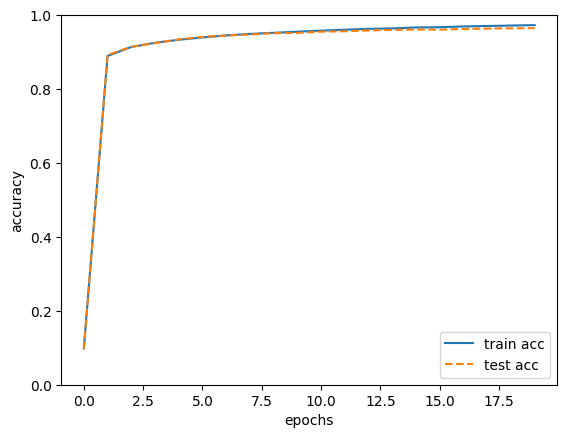

In [47]:
import sys, os
# 将上级目录添加到Python的搜索路径中，方便导入自定义模块
sys.path.append(os.pardir)  
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist


(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)

# 创建一个两层神经网络实例
# 输入层：784个神经元（MNIST图像是28×28=784个像素）
# 隐藏层：50个神经元
# 输出层：10个神经元（对应0~9十个数字分类）
network = TwoLayerNet(input_size=784, hidden_size=50, output_size=10)

# 训练总迭代次数（总共更新10000次参数）
iters_num = 12000  
# 训练集样本总数（60000张）
train_size = x_train.shape[0]
# 批次大小：每次训练随机抽取100个样本
batch_size = 100
# 学习率：控制参数更新的步长
learning_rate = 0.25

# 存储每一次迭代的训练损失值
train_loss_list = []
# 存储每一轮epoch的训练集准确率
train_acc_list = []
# 存储每一轮epoch的测试集准确率
test_acc_list = []

# 计算每一轮epoch需要的迭代次数
# 1个epoch = 遍历完所有训练样本一次（60000/100=600次迭代）
iter_per_epoch = max(train_size / batch_size, 1)

# 开始迭代训练
for i in range(iters_num):
    # 随机从训练集中选取batch_size个样本的索引
    batch_mask = np.random.choice(train_size, batch_size)
    # 根据索引取出对应的训练图像和标签
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]
    
    # 计算梯度（反向传播求梯度，速度远快于数值梯度）
    # grad = network.numerical_gradient(x_batch, t_batch)  # 数值梯度（慢，注释掉）
    grad = network.gradient(x_batch, t_batch)  # 反向传播梯度（快，实际使用）
    
    # 根据梯度更新网络参数（权重W和偏置b）
    for key in ('W1', 'b1', 'W2', 'b2'):
        network.params[key] -= learning_rate * grad[key]
    
    # 计算当前批次的损失值，并保存到列表
    loss = network.loss(x_batch, t_batch)
    train_loss_list.append(loss)
    
    # 每完成1个epoch（遍历完所有样本），计算并保存准确率
    if i % iter_per_epoch == 0:
        print(i, iter_per_epoch)
        # 计算在整个训练集上的准确率
        train_acc = network.accuracy(x_train, t_train)
        # 计算在整个测试集上的准确率
        test_acc = network.accuracy(x_test, t_test)
        # 将准确率存入列表
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)
        # 打印当前训练和测试准确率
        print("train acc, test acc | " + str(train_acc) + ", " + str(test_acc))

# 绘制准确率变化曲线
# 设置标记样式：训练集用圆圈，测试集用方块
markers = {'train': 'o', 'test': 's'}
# x轴：epoch的序号
x = np.arange(len(train_acc_list))
# 绘制训练集准确率曲线
plt.plot(x, train_acc_list, label='train acc')
# 绘制测试集准确率曲线（虚线）
plt.plot(x, test_acc_list, label='test acc', linestyle='--')
# x轴标签
plt.xlabel("epochs")
# y轴标签
plt.ylabel("accuracy")
# 设置y轴范围0~1（准确率范围）
plt.ylim(0, 1.0)
# 显示图例（右下角）
plt.legend(loc='lower right')
# 显示图像
plt.show()

In [49]:
network.params

{'W1': array([[ 0.01437037,  0.01340221, -0.00588131, ...,  0.00434165,
          0.01326183, -0.00182142],
        [-0.01378812, -0.00208038, -0.00350495, ...,  0.02195465,
         -0.00960244,  0.01507954],
        [-0.0066912 ,  0.00136526,  0.00219297, ..., -0.00203968,
         -0.00972808, -0.00396419],
        ...,
        [ 0.00606268, -0.01789454, -0.00447304, ..., -0.00448719,
          0.01728291,  0.00051387],
        [-0.0001544 ,  0.0129655 ,  0.00104869, ..., -0.00200603,
         -0.00593151,  0.01121591],
        [ 0.00967521, -0.00480998, -0.00200188, ..., -0.00219444,
          0.00766624,  0.0109552 ]], shape=(784, 50)),
 'b1': array([ 0.41508607,  0.55447321,  0.01725921, -0.20274395, -0.37546912,
        -0.43193062, -0.00255345, -0.47898432,  0.00758661, -0.07838324,
        -0.01015879,  0.45547786, -0.0938146 , -0.3390739 ,  0.12601254,
        -0.06053624, -0.02926295, -0.1497996 , -0.08583614,  0.01396845,
        -0.01150495,  0.09141133, -0.2226802 ,  0.04